# Entrenamiento de modelo usando kernel de kaggle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
import tensorflow as tf

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>0.95):
            print("\nCanceling training, enough accuracy (95%)!")
            self.model.stop_training = True

IndentationError: expected an indented block after function definition on line 7 (787215625.py, line 9)

In [17]:
callback = myCallback()

data_dir = '/kaggle/input/datasets/xxrelxx/faces-drone-cic/'
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

base_model = tf.keras.applications.MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model.trainable = False

Found 400 files belonging to 4 classes.
Using 320 files for training.
Found 400 files belonging to 4 classes.
Using 80 files for validation.


In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Resizing(128, 128),
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(800, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(512, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, 'relu',kernel_regularizer=tf.keras.regularizers.L1L2()),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    metrics=['acc']
)
modelH = model.fit(
    train_ds,
    steps_per_epoch=10,
    epochs=50,
    validation_data=train_ds,
    validation_steps=3,
    verbose=1,
    callbacks=[callback]
)

Epoch 1/50


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - acc: 0.2785 - loss: 1.8464

TypeError: '>' not supported between instances of 'NoneType' and 'float'

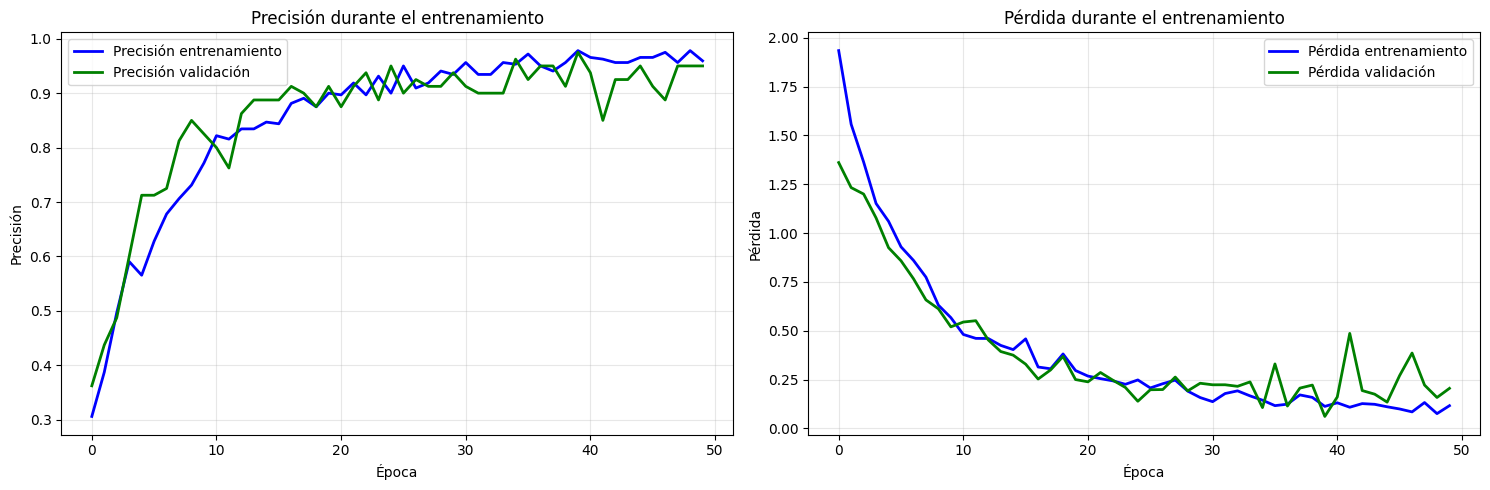

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


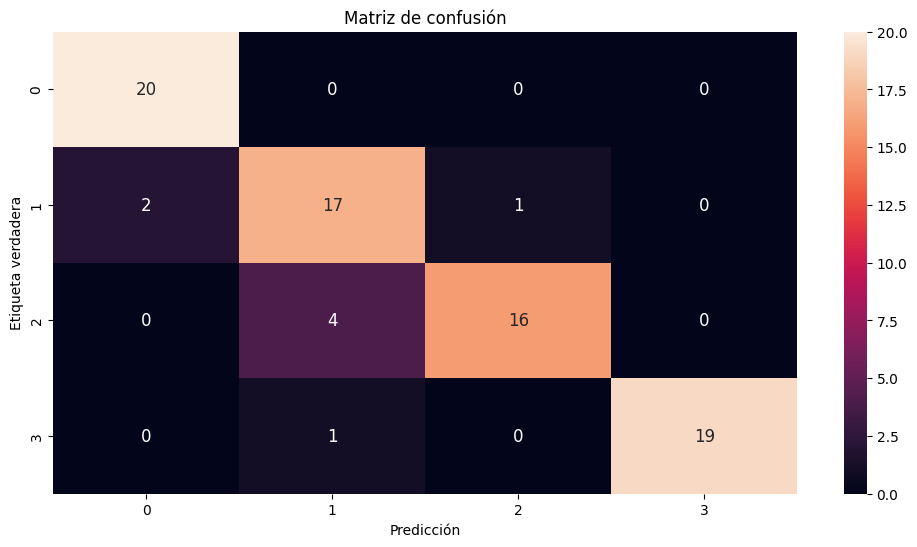

In [ ]:
# Crear figura con subplots horizontales (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Precisión
ax1.plot(modelH.history['acc'], label='Precisión entrenamiento', color='blue', linewidth=2)
ax1.plot(modelH.history['val_acc'], label='Precisión validación', color='green', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.set_title('Precisión durante el entrenamiento')
ax1.grid(True, alpha=0.3)

# Subplot 2: Pérdida
ax2.plot(modelH.history['loss'], label='Pérdida entrenamiento', color='blue', linewidth=2)
ax2.plot(modelH.history['val_loss'], label='Pérdida validación', color='green', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.set_title('Pérdida durante el entrenamiento')
ax2.grid(True, alpha=0.3)

# Ajustar espaciado y mostrar
plt.tight_layout()
plt.show()

# Obtener etiquetas verdaderas y predichas
y_true = []
y_pred = []

for i in range(len(val_ds)):
    x_batch, y_batch = val_ds[i]
    preds = model.predict(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

    # Opcional: detener si ya recorriste todo el set de validación
    if (i+1)*val_ds.batch_size >= len(val_ds)*val_ds.cardinality():
        break

import matplotlib.pyplot as plt
cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred)
# Plot the confusion matrix as a heatmap.
plt.figure(figsize=[12, 6])


sn.heatmap(cm, annot=True, fmt="d", annot_kws={"size": 12})
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.show()